<a href="https://colab.research.google.com/github/jhenningsen/Equity_Analysis/blob/main/TQQQ_VXN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TQQQ Trading Strategy Backtesting with VXN Volatility Regimes

This notebook develops and backtests systematic trading strategies for TQQQ (ProShares UltraPro QQQ 3x Leveraged ETF) using the ^VXN (CBOE Nasdaq 100 Volatility Index) as a volatility filter. The backtest period runs from TQQQ's inception date (February 11, 2010) to the present, utilizing adjusted prices from `yfinance`.

## Project Goals:
1.  **Develop a VXN-Regime Allocation Strategy:** Implement a strategy that dynamically adjusts TQQQ allocation based on VXN volatility.
2.  **Develop a Dynamic Volatility Scalper:** Create a contrarian strategy that aggressively expands exposure during market panics.
3.  **Compare Performance:** Evaluate both strategies against a TQQQ Buy and Hold benchmark using key metrics like CAGR, Max Drawdown, and visual equity curves.

## Strategy 1: VXN-Regime Allocation Strategy
*   **Core Concept:** A fully vectorized strategy that uses a 5-day Simple Moving Average (SMA) of VXN to determine the percentage of the portfolio allocated to TQQQ.
*   **Mechanics:** TQQQ allocation is dynamically adjusted based on predefined VXN volatility regimes. Lower VXN (Regime 0 & 1) leads to higher allocation, while higher VXN (Regime 2 & 3) reduces or eliminates TQQQ exposure.

## Strategy 2: Dynamic Volatility Scalper ("Buy the Blood")
*   **Core Concept:** A contrarian framework designed to harvest short-term equity premiums by aggressively expanding exposure during market panics (high VXN) and capturing a quick structural rebound.
*   **Execution Structure:** Implemented as an explicit Daily Loop Simulation tracking discrete sub-portfolios or "lots" via an open list array (`buy_lots = []`), allowing specific lot-level entry, valuation updates, and profit targets.

### Key Parameters:
*   `MIN_ALLOC = 0.40`: The permanent exposure floor; the account is never fully in cash.
*   `MAX_ALLOC = 1.00`: Maximum allowable portfolio leverage.
*   `VXN_FLOOR = 18.18`: Volatility baseline below which only the minimum floor is held.
*   `VXN_CEILING = 60.0`: Extreme panic threshold forcing maximum exposure.

### Algorithmic Allocation Logic:
*   **Daily Revaluation:** Every day, all active lots in `buy_lots` are revalued based on the current day's `TQQQ_Return`. Total portfolio value is updated as `Cash + Sum(Active Lots)`.
*   **Profit-Target Exits:** Each individual lot is monitored independently. If a lot achieves a `+20%` return from its specific entry cost basis, it is liquidated completely, and its capital is returned to the cash balance.
*   **Continuous Target Sizing:** A dynamic target allocation percentage (`target_alloc_pct`) is calculated using linear interpolation based on the current day's VXN value between the `VXN_FLOOR` and `VXN_CEILING`.
*   **Deficit Processing:** If the actual current allocation percentage drops below the dynamic target, the script calculates the absolute dollar deficit and deploys available cash into a new discrete lot entry.
*   **Floor Enforcement:** If the final allocation still sits below `MIN_ALLOC` (due to massive cash inflows from liquidated winning lots), a forced entry lot is generated to pull the baseline exposure back to 40%.

## Benchmark: TQQQ Buy and Hold
*   **Core Concept:** A pure, passive buy-and-hold baseline to evaluate strategy outperformance (Alpha) and risk-adjusted return profiles.
*   **Mechanics:** Fully vectorized execution. 100% of capital is deployed into TQQQ on day one, compounding daily based on TQQQ's fractional percent changes.
*   **Historical Performance:** Historically (2010–2026), this benchmark compounds at a ~40% to 44% CAGR, but suffers an extreme maximum drawdown of ~81.6% during the 2022 market regime shift.

In [47]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import seaborn as sns


## Strategy 1: VXN-Regime Allocation Strategy

In [42]:
# 1. Download 20 years of VXN and TQQQ data
tickers = ["^VXN", "TQQQ"]
data = yf.download(tickers, start="2010-02-11", end="2026-01-01")['Close'].dropna()

# 2. Fit an unsupervised GMM to the raw VXN price to discover the 4 clusters
X_vxn = data['^VXN'].values.reshape(-1, 1)
gmm = GaussianMixture(n_components=4, random_state=42, covariance_type='full')
raw_labels = gmm.fit_predict(X_vxn)

# 3. Sort the discovered regimes strictly by VXN level so 0 is lowest, 3 is highest
idx = np.argsort(gmm.means_.flatten())
state_map = {old_label: new_label for new_label, old_label in enumerate(idx)}
data['Regime'] = [state_map[label] for label in raw_labels]

# 4. View the naturally discovered boundaries
boundaries = data.groupby('Regime')['^VXN'].agg(['min', 'max', 'mean', 'count'])
print("--- DISCOVERED REGIMES ---")
print(boundaries)

/tmp/ipykernel_1121/2312670729.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2010-02-11", end="2026-01-01")['Close'].dropna()
[*********************100%***********************]  2 of 2 completed

--- DISCOVERED REGIMES ---
          min        max       mean  count
Regime                                    
0       10.31  18.170000  15.615453   1590
1       18.18  24.080000  20.603574   1346
2       24.09  35.450001  28.790000    892
3       35.48  80.080002  41.089704    169


In [43]:
# Calculate TQQQ daily log returns to evaluate performance
data['TQQQ_Return'] = np.log(data['TQQQ'] / data['TQQQ'].shift(1))

# Analyze TQQQ behavior inside each mathematically discovered regime
tqqq_analysis = data.groupby('Regime')['TQQQ_Return'].agg(['mean', 'std', 'count'])
# Annualize the returns and volatility for standard portfolio metrics
tqqq_analysis['Annualized_Return'] = tqqq_analysis['mean'] * 252
tqqq_analysis['Annualized_Vol'] = tqqq_analysis['std'] * np.sqrt(252)

print("\n--- TQQQ BEHAVIOR BY REGIME ---")
print(tqqq_analysis[['Annualized_Return', 'Annualized_Vol', 'count']])


--- TQQQ BEHAVIOR BY REGIME ---
        Annualized_Return  Annualized_Vol  count
Regime                                          
0                1.498607        0.328550   1590
1                0.481887        0.498203   1345
2               -0.510911        0.842802    892
3               -6.972579        1.409376    169


In [51]:
data['VXN_5_SMA'] = data['^VXN'].rolling(window=5).mean()
data['TQQQ_Daily_Return'] = data['TQQQ'].pct_change()
data = data.dropna().copy()

conditions = [
    (data['VXN_5_SMA'] < 18.18),
    (data['VXN_5_SMA'] >= 18.18) & (data['VXN_5_SMA'] < 24.09),
    (data['VXN_5_SMA'] >= 24.09)
]

MAX_ALLOCATION = 1
allocations = [MAX_ALLOCATION, MAX_ALLOCATION, 0.0]

data['Target_Weight'] = np.select(conditions, allocations, default=0.0)
data['Allocated_Weight'] = data['Target_Weight'].shift(1)
data = data.dropna().copy()

data['Strategy_Daily_Return'] = data['Allocated_Weight'] * data['TQQQ_Daily_Return']

initial_portfolio_value = 100000.0
data['Strategy_Equity'] = (1 + data['Strategy_Daily_Return']).cumprod() * initial_portfolio_value
data['Benchmark_Equity'] = (1 + data['TQQQ_Daily_Return']).cumprod() * initial_portfolio_value

def calculate_metrics(return_series, equity_series, initial_value):
    total_return = (equity_series.iloc[-1] / initial_value - 1) * 100
    years = len(equity_series) / 252
    cagr = ((equity_series.iloc[-1] / initial_value) ** (1 / years) - 1) * 100
    ann_vol = return_series.std() * np.sqrt(252) * 100
    sharpe = cagr / ann_vol if ann_vol != 0 else 0

    rolling_max = equity_series.cummax()
    drawdowns = (equity_series - rolling_max) / rolling_max
    max_dd = drawdowns.min() * 100
    return cagr, ann_vol, sharpe, max_dd

strat_cagr, strat_vol, strat_sharpe, strat_mdd = calculate_metrics(data['Strategy_Daily_Return'], data['Strategy_Equity'], initial_portfolio_value)
bench_cagr, bench_vol, bench_sharpe, bench_mdd = calculate_metrics(data['TQQQ_Daily_Return'], data['Benchmark_Equity'], initial_portfolio_value)

final_strat_equity = data['Strategy_Equity'].iloc[-1]
final_bench_equity = data['Benchmark_Equity'].iloc[-1]

val_strat_str = f"${final_strat_equity:,.2f}"
val_bench_str = f"${final_bench_equity:,.2f}"
cagr_strat_str = f"{strat_cagr:.2f}%"
cagr_bench_str = f"{bench_cagr:.2f}%"
mdd_strat_str = f"{strat_mdd:.2f}%"
mdd_bench_str = f"{bench_mdd:.2f}%"

print(f"{'Metric':<25}{'VXN-Regime Strategy':<25}{'TQQQ Buy & Hold':<20}")
print("-" * 70)
print(f"{'Ending Portfolio Value':<25}{val_strat_str:<25}{val_bench_str:<20}")
print(f"{'CAGR':<25}{cagr_strat_str:<25}{cagr_bench_str:<20}")
print(f"{'Annualized Vol':<25}{f'{strat_vol:.2f}%':<25}{f'{bench_vol:.2f}%':<20}")
print(f"{'Sharpe Ratio':<25}{f'{strat_sharpe:.2f}':<25}{f'{bench_sharpe:.2f}':<20}")
print(f"{'Max Drawdown':<25}{mdd_strat_str:<25}{mdd_bench_str:<20}")
print("-" * 70)

Metric                   VXN-Regime Strategy      TQQQ Buy & Hold     
----------------------------------------------------------------------
Ending Portfolio Value   $9,006,303.69            $22,273,787.13      
CAGR                     32.95%                   40.79%              
Annualized Vol           37.75%                   61.18%              
Sharpe Ratio             0.87                     0.67                
Max Drawdown             -49.11%                  -81.66%             
----------------------------------------------------------------------


### Strategy 1: VXN-Regime Allocation Strategy Equity Curve

This plot visualizes the performance of the VXN-Regime Allocation Strategy over the backtest period.

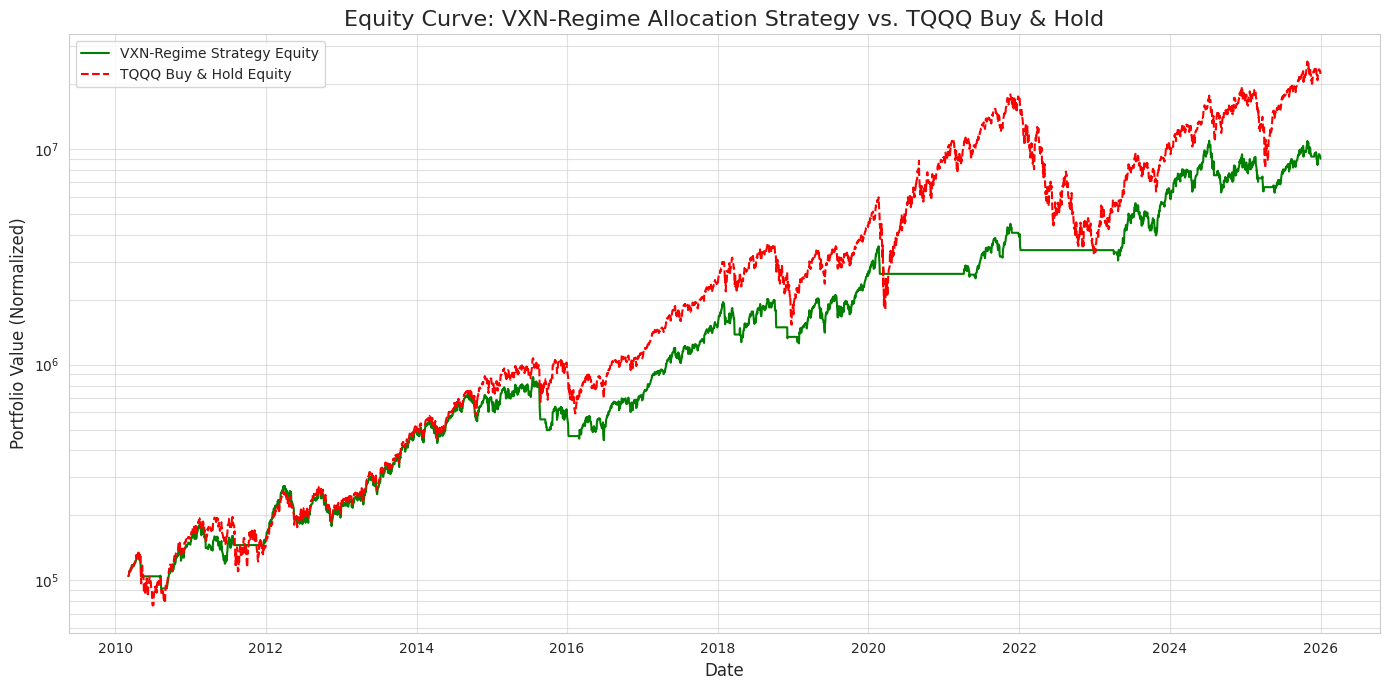

In [52]:
sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))

plt.plot(data.index, data['Strategy_Equity'], label='VXN-Regime Strategy Equity', color='green')
plt.plot(data.index, data['Benchmark_Equity'], label='TQQQ Buy & Hold Equity', color='red', linestyle='--')

plt.title('Equity Curve: VXN-Regime Allocation Strategy vs. TQQQ Buy & Hold', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value (Normalized)', fontsize=12)
plt.legend(fontsize=10)
plt.yscale('log') # Use log scale for better visualization of exponential growth
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

### Strategy 2: Dynamic Volatility Scalper ("Buy the Blood") - Data Acquisition

This section fetches the historical price data for ^VXN and TQQQ using `yfinance` and prepares it for the backtesting process. Adjusted close prices are used to account for corporate actions, ensuring accurate historical pricing for both assets.

In [45]:
# 1. Fetch data independently to avoid yfinance multi-index column bugs
# We set the start to 2010-02-11 to match TQQQ's real-world inception
vxn_raw_data = yf.download("^VXN", start="2010-02-11", end="2026-01-01", auto_adjust=True)
vxn_df = vxn_raw_data['Close']
vxn_df.columns = ['VXN']

tqqq_raw_data = yf.download("TQQQ", start="2010-02-11", end="2026-01-01", auto_adjust=True)
tqqq_df = tqqq_raw_data['Close']
tqqq_df.columns = ['TQQQ']

# Combine them cleanly on matching dates
df = vxn_df.join(tqqq_df, how='inner')
df['TQQQ_Return'] = df['TQQQ'].pct_change()
df = df.dropna()

# 2. Simulation Variables
portfolio_value = 100000.0  # Starting with $100k
cash = portfolio_value
buy_lots = []               # Tracking active lots
strategy_equity = []

MIN_ALLOC = 0.40
MAX_ALLOC = 1.00
VXN_FLOOR = 18.18
VXN_CEILING = 60.0

# 3. Corrected Daily Simulation Loop
for date, row in df.iterrows():
    vxn = row['VXN']
    tqqq_price = row['TQQQ']
    tqqq_ret = row['TQQQ_Return']

    # Update valuation of held lots
    total_tqqq_value = 0.0
    for lot in buy_lots:
        lot['current_value'] = lot['current_value'] * (1 + tqqq_ret)
        total_tqqq_value += lot['current_value']

    portfolio_value = cash + total_tqqq_value

    # Check Exits (+20% profit target per lot)
    retained_lots = []
    for lot in buy_lots:
        current_gain = (lot['current_value'] / lot['allocated_cash']) - 1.0
        if current_gain >= 0.20:
            cash += lot['current_value']
        else:
            retained_lots.append(lot)

    buy_lots = retained_lots
    total_tqqq_value = sum(lot['current_value'] for lot in buy_lots)
    current_alloc_pct = total_tqqq_value / portfolio_value

    # Continuous Target Curve
    if vxn <= VXN_FLOOR:
        target_alloc_pct = MIN_ALLOC
    elif vxn >= VXN_CEILING:
        target_alloc_pct = MAX_ALLOC
    else:
        target_alloc_pct = MIN_ALLOC + ((vxn - VXN_FLOOR) / (VXN_CEILING - VXN_FLOOR)) * (MAX_ALLOC - MIN_ALLOC)

    # Process Sizing Deficits
    if target_alloc_pct > current_alloc_pct:
        alloc_deficit_pct = target_alloc_pct - current_alloc_pct
        cash_to_deploy = portfolio_value * alloc_deficit_pct
        if cash_to_deploy > cash:
            cash_to_deploy = cash
        if cash_to_deploy > 0:
            buy_lots.append({
                'cost_basis': tqqq_price,
                'allocated_cash': cash_to_deploy,
                'current_value': cash_to_deploy
            })
            cash -= cash_to_deploy

    # Core 40% Floor Enforcement
    current_tqqq_sum = sum(lot['current_value'] for lot in buy_lots)
    if (current_tqqq_sum / portfolio_value) < MIN_ALLOC:
        deficit = (portfolio_value * MIN_ALLOC) - current_tqqq_sum
        if deficit > cash:
            deficit = cash
        if deficit > 0:
            buy_lots.append({
                'cost_basis': tqqq_price,
                'allocated_cash': deficit,
                'current_value': deficit
            })
            cash -= deficit

    portfolio_value = cash + sum(lot['current_value'] for lot in buy_lots)
    strategy_equity.append(portfolio_value)

df['Strategy_Equity'] = strategy_equity

# 4. Clean Vectorized Calculation for the True Benchmark
df['Benchmark_Equity'] = (1 + df['TQQQ_Return']).cumprod() * 100000.0

# 5. Performance Scorecard Calculations
final_strat_equity = df['Strategy_Equity'].iloc[-1]
final_bench_equity = df['Benchmark_Equity'].iloc[-1]

years = len(df) / 252
strat_cagr = ((final_strat_equity / 100000.0) ** (1 / years) - 1) * 100
bench_cagr = ((final_bench_equity / 100000.0) ** (1 / years) - 1) * 100

def get_max_drawdown(equity_series):
    rolling_max = equity_series.cummax()
    drawdowns = (equity_series - rolling_max) / rolling_max
    return drawdowns.min() * 100

strat_mdd = get_max_drawdown(df['Strategy_Equity'])
bench_mdd = get_max_drawdown(df['Benchmark_Equity'])

# Formatted Output
val_strat_str = f"${final_strat_equity:,.2f}"
val_bench_str = f"${final_bench_equity:,.2f}"
cagr_strat_str = f"{strat_cagr:.2f}%"
cagr_bench_str = f"{bench_cagr:.2f}%"
mdd_strat_str = f"{strat_mdd:.2f}%"
mdd_bench_str = f"{bench_mdd:.2f}%"

print(f"\n{'Metric':<25}{'Contrarian Strategy':<25}{'TQQQ Buy & Hold':<20}")
print("-" * 70)
print(f"{'Ending Portfolio Value':<25}{val_strat_str:<25}{val_bench_str:<20}")
print(f"{'CAGR':<25}{cagr_strat_str:<25}{cagr_bench_str:<20}")
print(f"{'Max Drawdown':<25}{mdd_strat_str:<25}{mdd_bench_str:<20}")
print("-" * 70)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



Metric                   Contrarian Strategy      TQQQ Buy & Hold     
----------------------------------------------------------------------
Ending Portfolio Value   $6,070,158.88            $25,543,131.84      
CAGR                     29.55%                   41.84%              
Max Drawdown             -61.71%                  -81.66%             
----------------------------------------------------------------------


### Strategy Two Equity Curves

Let's plot the equity curves of both strategies to visually compare their performance over the backtest period.

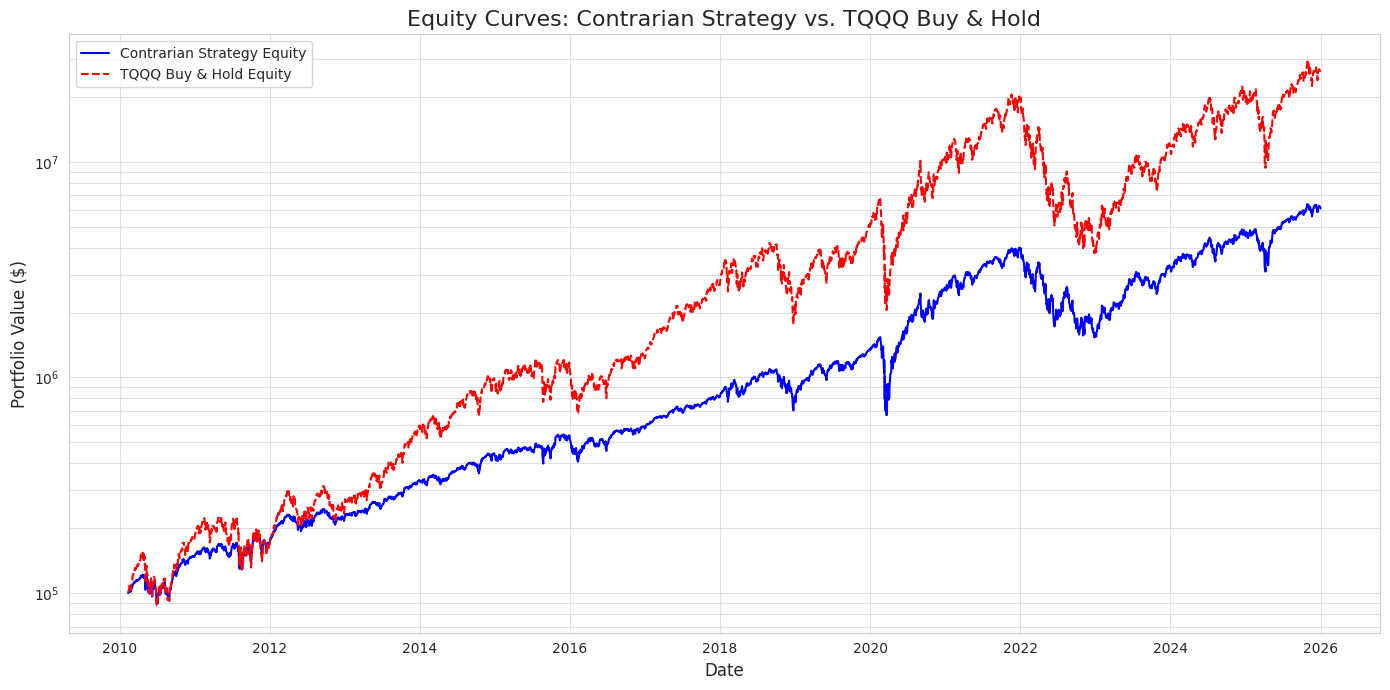

In [46]:
# Visualize the equity curves of the strategy two
sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))

plt.plot(df.index, df['Strategy_Equity'], label='Contrarian Strategy Equity', color='blue')
plt.plot(df.index, df['Benchmark_Equity'], label='TQQQ Buy & Hold Equity', color='red', linestyle='--')

plt.title('Equity Curves: Contrarian Strategy vs. TQQQ Buy & Hold', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value ($)', fontsize=12)
plt.legend(fontsize=10)
plt.yscale('log') # Use log scale for better visualization of exponential growth
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()
